In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from astropy import units as u
import pandas as pd
# from dsph_analysis import kinematic_io
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
from dsph_analysis import kinematic_io

In [2]:
# catalog_path = '/home/jupyter-tvnguyen/datasets/mock_catalogs/icrs/mock_data/MockA.csv'
catalog_path = './draco1_walker23_noSF_blind/MockA.csv'
meta = kinematic_io.load_meta('draco_1')
data = kinematic_io.load_kinematic_data(
    catalog_path,
    meta,
    source='mock_icrs',
    vlos_err_floor=0.0,
    apply_perspective_corr=True,
)

In [6]:
# np.log10(meta.rhalf_kpc.value)
print(meta.rhalf_kpc.value, 0.5 * (meta.rhalf_kpc_em + meta.rhalf_kpc_ep))


0.22924 0.004695 kpc


In [7]:
X_proj = data.X_proj.value
Y_proj = data.Y_proj.value
R_proj = data.R_proj.value
vlos = data.vlos.value
vlos_err = data.vlos_err.value

(200,)

In [5]:
np.testing.assert_almost_equal(R_proj, np.sqrt(X_proj**2 + Y_proj**2))

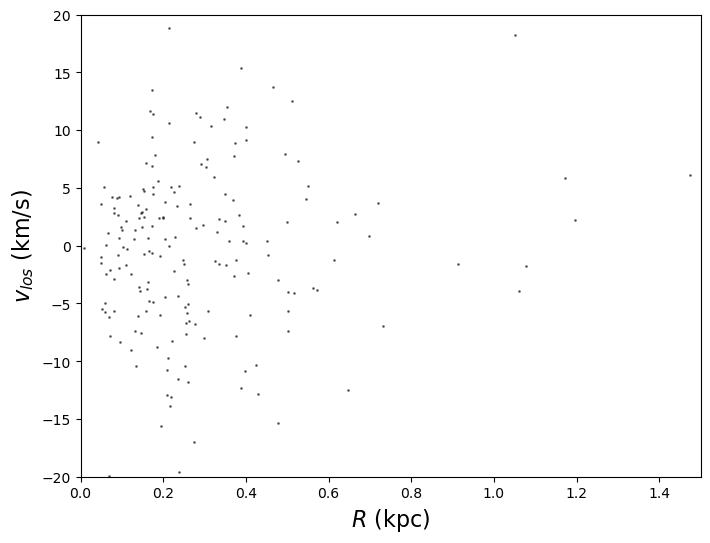

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(R_proj, vlos, s=1, color='k', alpha=0.5)
ax.set_xlim(0, 1.5)
ax.set_ylim(-20, 20)
ax.set_xlabel(r"$R$ (kpc)", fontsize=16)
ax.set_ylabel(r"$v_{los}$ (km/s)", fontsize=16)
# cbar.set_label("Number density", fontsize=16)
plt.show()

# Generate

In [7]:

mock = "D"
catalog_path = f'./draco1_walker23_noSF_blind/Mock{mock}.csv'
meta = kinematic_io.load_meta('draco_1')
data = kinematic_io.load_kinematic_data(
    catalog_path,
    meta,
    source='mock_icrs',
    vlos_err_floor=0.0,
    apply_perspective_corr=True,
)
X_proj = data.X_proj.value
Y_proj = data.Y_proj.value
R_proj = data.R_proj.value
vlos = data.vlos.value
vlos_err = data.vlos_err.value

array = np.zeros((200, 3))
array[:, 0], array[:, 1], array[:, 2] = X_proj, Y_proj, vlos
 
array

pd.DataFrame(array).to_csv(f"./8d_theta/model_8/mock_noSF/data/Mock{mock}_refined.csv", header=None, index=None)
pd.DataFrame(vlos_err).to_csv(f"./8d_theta/model_8/mock_noSF/data/Mock{mock}_unc.csv", header=None, index=None)